In [28]:
import numpy as np
import marimo as mo
import casadi as ca
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Projet optimisation

# Partie 1 :

1. * $P_i \Delta t$ correspond à l'énergie utilisée entre $t_i$ et $t_{i+1}$.
   * $c_i$ correspond au prix d'une unité d'énergie à l'instant $t_i$.  
    Donc le prix total est bien : $$\Delta t \sum_{i=0}^{N} P_i c_i$$

2. $$T_{i+1} = e^{-(k+h)\Delta t}T_i + \frac{1-e^{-(k+h)\Delta t}}{k+h}(bP_i + hT_e^i)$$

Cette équation vient du premier principe de la thermodynamique appliqué à la pièce de capacité calorifique 1/b entre $t_i$ et $t_{i+1}$. On obtient en fait une équation différentielle du premier ordre car $P_i$ et $T_e^i$ sont constant entre $t_i$ et $t_{i+1}$, qu'on peut facilement résoudre. Les termes suivants sont les puissances apportées entre $t_i$ et $t_{i+1}$:
* $Resistance$ $thermique*(T_e^i - T)$ : puissance reçue par l'extérieur (on a $h = \frac{1}{c*Resistance thermique}$)
* $P_i$ : puissance reçue par le chauffage
* $-kT$ : d'autres fuites thermiques pas liées à l'extérieur.

$\frac{1}{h}$ est le temps caractéristique lié spécifiquement aux échanges avec l'extérieur. $\frac{1}{k}$ est le temps caractéristique lié aux pertes intrinsèques du bâtiment
$\frac{1}{k+h}$ correspond au temps caractéristique de la perte globale de chaleur.


3. __Variables de décision__ : Les puissances $(P_i)_{i \in [0,N]}$ et les températures $(T_i)_{i \in [0,N]}$. Il y en a donc $2(N+1)$ variables. On regroupe toutes ces variables dans un vecteur $$x = \begin{bmatrix} P_0 \\ P_1 \\ \vdots \\ P_N \\ T_0 \\ T_1 \\ \vdots \\ T_N \end{bmatrix}\in \mathbb{R}^{2N+2}$$
__Contraintes d'égalité__ : il y'en a $N+2$ (Les N équations du premier principe et les 2 conditions initiales/terminales).
$$
\begin{array}{rcl}
c_{eq}:\mathbb{R}^{2N+2}&\to& \mathbb{R}^{N+2}\\
x &\mapsto &\begin{bmatrix} 
T_0 - T_{in} \\ 
P_N \\ 
T_1 - \Phi T_0 - \Psi (bP_0 + hT_e^0) \\ 
T_2 - \Phi T_1 - \Psi (bP_1 + hT_e^1) \\ 
\vdots \\ 
T_N - \Phi T_{N-1} - \Psi (bP_{N-1} + hT_e^{N-1}) 
\end{bmatrix}
\end{array}
$$
__Contraintes d'inégalité__: il y'en a $N+2$
$$
\begin{array}{rcl}
c_{eq}:\mathbb{R}^{2N+2}&\to& \mathbb{R}^{2(N+1+|I_{occ}|)}\\
x &\mapsto &\begin{bmatrix} 
P_0 - P_M \\ 
\vdots \\ 
P_N - P_M \\ 
-P_0 \\ 
\vdots \\ 
-P_N \\ 
T_m - T_{i_1} \\ 
\vdots \\ 
T_m - T_{i_{|I_{occ}|}} \\ 
T_{i_1} - T_M \\ 
\vdots \\ 
T_{i_{|I_{occ}|}} - T_M
\end{bmatrix}
\end{array}
$$

__Fonction objectif à minimiser__ : $f(x) = \Delta t \sum_{i=0}^{N} c_i P_i$.

Ainsi, le problème d'optimisation à résoudre est
$$
\begin{aligned}
\min_{x} \quad & f(x) \\
\text{tel que} \quad & c_{eq}(x) = 0, \\
& c_{in}(x) \leq 0
\end{aligned}
$$

4. * La fonction objectif $f$ est linéaire, donc convexe.
   * Les contraintes d'égalité $c_{eq}$ et d'inégalités $c_{in}$ sont aussi linéaires, donc convexes.
Le problème est donc convexe. Encore mieux, comme tout est linéaire, on a un problème linéaire. 

# Partie 2 :

5. Le problème étant linéaire, on pourrait utiliser l'algorithme du simplexe pour le résoudre. On peut aussi utiliser la méthode des points intérieurs, ce qu'on va faire avec une résolution numérique avec Casadis.

6. Résolution:

In [29]:
#définition des constantes:
delta_t = 0.3
t_0 = 23
c_cr = 1
c_pl = 3/2
T_m = 18
T_M = 30
T_in = T_m
h = 0.05
k = 0.01
b = 1/500
P_M = 5000
N = int(24/delta_t)
I_occ = []
cost = []
h_creuse = []
h_pleine = []

for i in range(N+1):
    hour = (t_0 + delta_t*i)%24
    if (hour >= 7 and hour <= 9) or (hour >= 18 and hour <= 23):
        I_occ.append(i)
    if (hour >= 0 and hour <= 6) or (hour >= 12 and hour <= 14):
        h_creuse.append(i)
        cost.append(c_cr)
    else:
        h_pleine.append(i)
        cost.append(c_pl)





#Fonction température extérieure:

def temp_ext(t):
    return 4 + 8*np.exp(-(t%24-12)**2/40)


In [30]:
P = ca.SX.sym('P', N+1)
T = ca.SX.sym('T', N+1)
x = ca.vertcat(P, T)

obj = delta_t*ca.dot(P, cost)

lbx = []
ubx = []

#bornes sur les Pi
for i in range(N):
    lbx.append(0)
    ubx.append(P_M)

#contraintes PN=0 et T0=Tin
lbx.append(0)
ubx.append(0)
lbx.append(T_in)
ubx.append(T_in)

#contraintes de confort sur les Ti pour i dans Iocc
for i in range(1, N+1):
    if i in I_occ:
        lbx.append(T_m)
        ubx.append(T_M)
    else:
        lbx.append(-ca.inf)
        ubx.append(ca.inf)

In [31]:
g = [T[i+1] - np.exp(-(k+h)*delta_t)*T[i] - (1-np.exp(-(k+h)*delta_t))/(k+h)*(b*P[i]+h*temp_ext((t_0 + delta_t*i)%24)) for i in range(N)]
lbg = [0 for i in range(N)]
ubg = [0 for i in range(N)]

g = ca.vertcat(*g)


In [32]:
lp = {
    'x': x,
    'f': obj,
    'g': g,
}

solver = ca.qpsol(
    'solver',
    'highs',
    lp
)

sol = solver(
    lbx=lbx,
    ubx=ubx,
    lbg=lbg,
    ubg=ubg
)

Puissance_sol = sol['x'][:N+1]
Temperature_sol = sol['x'][N+1:]

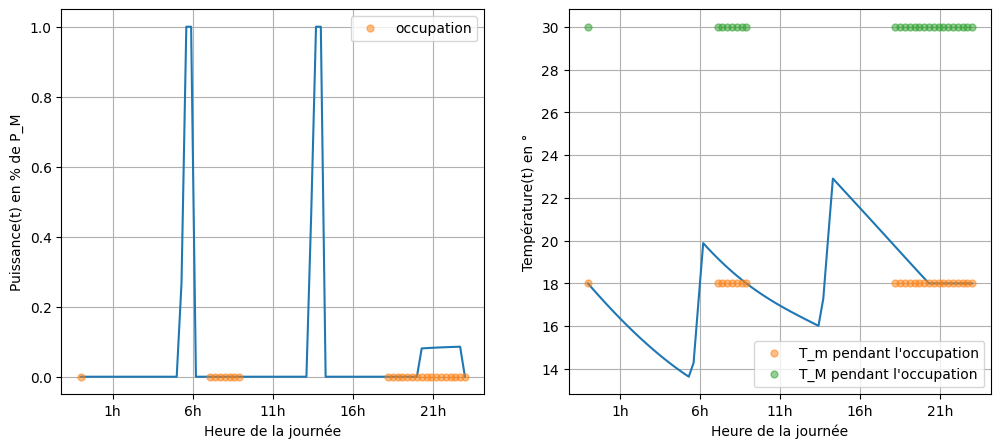

In [33]:
time_axis = [t_0 + delta_t * i for i in range(N+1)]
time_occ = [t_0 + delta_t * i for i in I_occ]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol/P_M)
axs[0].set_ylabel("Puissance(t) en % de P_M")
axs[0].plot(time_occ, [0 for i in range(len(time_occ))], marker='o', markersize=5, linewidth=0, alpha = 0.5, label = "occupation")
axs[1].plot(time_axis, Temperature_sol)
axs[1].plot(time_occ, [T_m for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_m pendant l'occupation")
axs[1].plot(time_occ, [T_M for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_M pendant l'occupation")
axs[1].set_ylabel("Température(t) en °")

def format_func(value, tick_number):
    return f"{int(value % 24)}h"

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

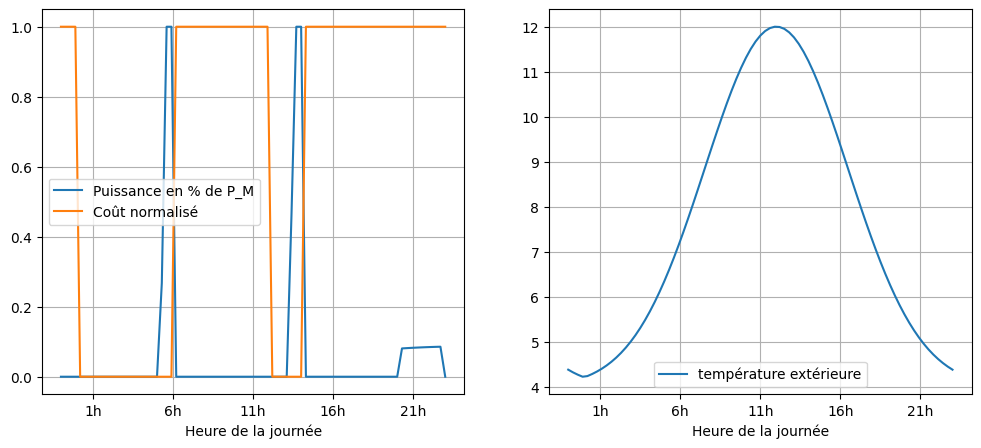

In [34]:
cost_normalized = [(cost[i]-c_cr)/(c_pl-c_cr) for i in range(len(cost))]
tempext = [temp_ext(t) for t in time_axis]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol/P_M, label="Puissance en % de P_M")
axs[0].plot(time_axis, cost_normalized, label = "Coût normalisé")
axs[1].plot(time_axis, tempext, label = "température extérieure")


for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

__Commentaires__: Le chauffage s'allume le plus tard possible dans la période creuse, pour payer moins cher tout en assurant les bornes des températures pendant les périodes d'occupation. On remarque cependant que à partir de 20h, la température allait passer en dessous de la borne inférieure, le chauffage se rallume donc, mais seulement assez pour assurer une température égale à la borne inférieure pendant la période pleine.

7. En augmentant le tarif heure pleine, on observe que le petit maintien de puissance en heure pleine (qu'ob observait à 20h dans la question précédente) disparaît complètement. Pour compenser ce manque à gagner thermique pendant la période d'occupation, le solveur allonge la durée de chauffe à pleine puissance ($P_M$) pendant les heures creuses. Le tarif a donc vraiment un effet incitatif sur le client, qui adapte sa stratégie de consommation pour payer le moins cher possible.